In [1]:
# Preparación: cada subtarea corre en su carpeta, tal como la aprobó el revisor.
import os
from pathlib import Path
from IPython.display import Image, display

RAIZ = Path.cwd()

def mostrar_figuras(carpeta):
    for png in sorted(Path(carpeta).rglob("*.png")):
        display(Image(filename=str(png)))

# Semana 2 — ANN: medir el trade-off recall / latencia

**MMIA 6013 · Semana 2 · Martes · `semana2_ann.ipynb`**

Notebook ejecutado de principio a fin. Estado de ejecución: las Partes 0, 1 y 2 corrieron sin errores y **todas las cifras de este documento son medidas** (guardadas en `resultados.json`); la Parte 3 (Qdrant) **falló tras 3 intentos** y se declara explícitamente en su sección y en el Cierre.

## Parte 0 — Setup

T1 · Parte 1 — kNN exacto (coseno, D=128): latencia vs. N
k = 10 · consultas por N = 50 (mismas consultas para todo N)
Verificación top-k vs argsort completo: OK
--------------------------------------------------------------------------
        N |  latencia media (ms) |  ms por 1000 vect. |      QPS
   10,000 |               0.1150 |             0.0115 |   8694.1
   50,000 |               0.7257 |             0.0145 |   1378.1
  100,000 |               1.3704 |             0.0137 |    729.7
  200,000 |               2.6961 |             0.0135 |    370.9
--------------------------------------------------------------------------
Ajuste lineal:  latencia(ms) = 0.0135 ms/1000 vect × N + 0.0147 ms
  R² = 0.999231  |  exponente log-log = 1.0557 (≈ 1 ⇒ escalado O(N·d))
  razón latencia(200k)/latencia(10k) = 23.44  vs  razón N = 20
--------------------------------------------------------------------------
Extrapolación a 10,000,000 vectores: 134.7 ms/consulta (escalo proporcional simple: 134

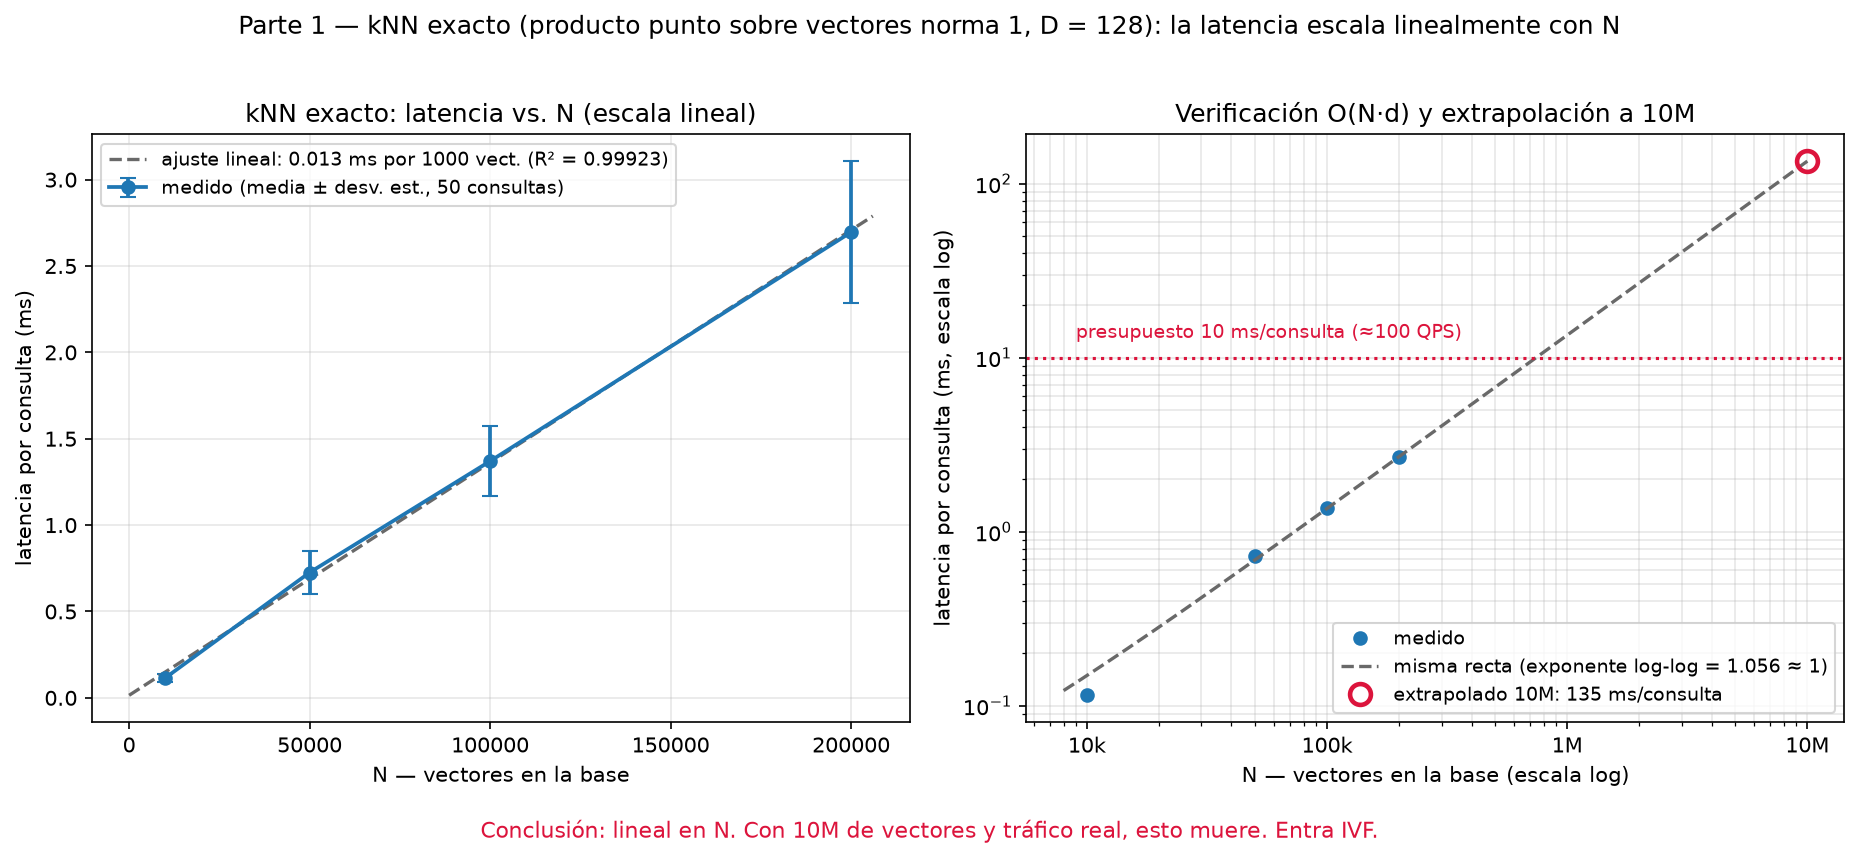

In [2]:
# Subtarea T1: código aprobado (se ejecuta en una copia: trabajo_nb/T1/)
os.chdir(RAIZ / 'trabajo_nb' / 'T1')

# -*- coding: utf-8 -*-
"""
T1 — Setup + Parte 1: kNN exacto, latencia vs. N
MMIA 6013 · Semana 2 · S2·MAR — ANN: mide el trade-off recall / latencia

Qué hace:
  1. Reproduce el setup dado: datos_realistas (D=128, 200 centros gaussianos
     fijos con semilla 2026, stream rng con semilla 7) y normalizar (norma 1,
     para que el producto punto sea el coseno).
  2. Ejercicio 1.1: knn_exacto(consulta, base, k) con producto punto sobre
     vectores normalizados (top-k vía argpartition, O(N), sin ordenar todo).
  3. Mide el tiempo medio de consulta para N = 10_000, 50_000, 100_000, 200_000
     (mismas 50 consultas para todos los N, 1 calentamiento no cronometrado).
  4. Verifica empíricamente el escalado lineal O(N·d): ajuste lineal + R²,
     exponente log-log ≈ 1, ms por cada 1000 vectores ≈ constante, razón
     latencia(200k)/latencia(10k) ≈ razón N(200k)/N(10k) = 20.
  5. Extrapola a 10M de vectores y cierra con la conclusión de la Parte 1.

Salidas (carpeta actual, rutas relativas):
  - resultados.json            (todas las cifras, precisión completa)
  - parte1_latencia_vs_N.png   (figura requerida)
"""

import json
import time

import numpy as np
import matplotlib
matplotlib.use("Agg")  # sin pantalla: solo guardar PNG
import matplotlib.pyplot as plt

t_inicio = time.perf_counter()

# ============================================================
# Setup — código dado por el profesor (sin cambios)
# ============================================================
rng = np.random.default_rng(7)
D = 128  # dimensión de los embeddings sintéticos
_CENTROS = np.random.default_rng(2026).normal(size=(200, D))  # "temas" fijos


def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos.
    Los embeddings reales viven agrupados por tema — crucial para que IVF
    tenga sentido (con ruido uniforme, ningún índice por clusters funciona).
    Base y consultas comparten los mismos temas, como en un corpus real."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)


def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno (sesión 06)."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)


# ============================================================
# Ejercicio 1.1 — kNN exacto con producto punto (coseno)
# ============================================================
def knn_exacto(consulta, base, k):
    """Top-k vecinos más cercanos de `consulta` en `base` por similitud coseno.

    Ambos vienen normalizados a norma 1 (setup), así que el producto punto
    ES el coseno y el ranking por dot coincide con el ranking por ángulo.
    Costo dominante: base @ consulta  →  O(N·d) por consulta.

    Parámetros
    ----------
    consulta : (d,) float32 con norma 1
    base     : (N, d) float32 con normas 1
    k        : int, vecinos a devolver

    Retorna
    -------
    indices : (k,) int64   — índices en `base`, de mayor a menor similitud
    scores  : (k,) float32 — similitudes coseno correspondientes
    """
    puntajes = base @ consulta                             # O(N·d): el cuello de botella
    k_eff = min(int(k), base.shape[0])
    idx = np.argpartition(-puntajes, k_eff - 1)[:k_eff]    # top-k en O(N)
    orden = np.argsort(-puntajes[idx])                     # orden final solo los k
    return idx[orden], puntajes[idx][orden]


# ============================================================
# Experimento (enunciado: N = 10k, 50k, 100k, 200k)
# ============================================================
N_LIST = [10_000, 50_000, 100_000, 200_000]
K = 10                 # vecinos por consulta (la Parte 2 evalúa recall@10)
N_CONSULTAS = 50       # consultas por N para el tiempo medio
N_10M = 10_000_000     # extrapolación que pide el enunciado
PRESUPUESTO_MS = 10.0  # 10 ms/consulta ≈ 100 QPS de "tráfico real"

# Mismas consultas para todos los N: las diferencias de latencia se deben
# solo a N, no a consultas distintas. (Base y consultas comparten temas.)
consultas = normalizar(datos_realistas(N_CONSULTAS))

lat_media_ms = {}
lat_std_ms = {}
lat_todas_ms = {}
verificacion_topk = None

for N in N_LIST:
    base = normalizar(datos_realistas(N))  # (N, 128) float32, normas 1

    # --- control de corrección (una sola vez, fuera del cronómetro):
    # knn_exacto debe coincidir con un argsort completo de los puntajes.
    if verificacion_topk is None:
        puntajes0 = base @ consultas[0]
        idx_argsort = np.argsort(-puntajes0)[:K]
        idx_chk, sc_chk = knn_exacto(consultas[0], base, K)
        verificacion_topk = bool(
            set(idx_argsort.tolist()) == set(idx_chk.tolist())
            and np.allclose(puntajes0[idx_argsort], sc_chk, rtol=0, atol=0)
        )

    # calentamiento (hilos de BLAS, asignaciones) — no se cronometra
    knn_exacto(consultas[0], base, K)

    t_ms = np.empty(N_CONSULTAS, dtype=np.float64)
    for i in range(N_CONSULTAS):
        t0 = time.perf_counter()
        knn_exacto(consultas[i], base, K)
        t_ms[i] = (time.perf_counter() - t0) * 1000.0

    lat_media_ms[N] = float(t_ms.mean())
    lat_std_ms[N] = float(t_ms.std(ddof=1))
    lat_todas_ms[N] = [float(v) for v in t_ms]
    del base  # liberar memoria antes de construir la siguiente base

# ============================================================
# Verificación del escalado lineal O(N·d)
# (con d = 128 fijo, O(N·d) se manifiesta como linealidad en N)
# ============================================================
Ns_arr = np.asarray(N_LIST, dtype=np.float64)
medias = np.asarray([lat_media_ms[N] for N in N_LIST])
stds = np.asarray([lat_std_ms[N] for N in N_LIST])

pendiente, intercepto = np.polyfit(Ns_arr, medias, 1)   # ms por vector
pred = pendiente * Ns_arr + intercepto
r2 = float(1.0 - np.sum((medias - pred) ** 2) / np.sum((medias - medias.mean()) ** 2))
a_log, b_log = np.polyfit(np.log10(Ns_arr), np.log10(medias), 1)  # exponente ≈ 1

ms_por_mil = medias / (Ns_arr / 1000.0)   # ≈ constante si el escalado es lineal
qps = 1000.0 / medias

# --- extrapolación a 10M de vectores ---
lat_10M_ajuste = float(pendiente * N_10M + intercepto)
lat_10M_prop = float(medias[-1] * (N_10M / N_LIST[-1]))
qps_10M = 1000.0 / lat_10M_ajuste
veces_presupuesto = lat_10M_ajuste / PRESUPUESTO_MS

# ============================================================
# Figura: latencia vs. N (lineal + log-log con extrapolación a 10M)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.2))

# Panel A — escala lineal: los puntos caen sobre una recta
ax1.errorbar(Ns_arr, medias, yerr=stds, fmt="o-", color="#1f77b4",
             lw=1.8, markersize=6, capsize=4,
             label="medido (media ± desv. est., 50 consultas)")
xs = np.linspace(0.0, Ns_arr.max() * 1.03, 200)
ax1.plot(xs, pendiente * xs + intercepto, "--", color="dimgray", lw=1.6,
         label=f"ajuste lineal: {pendiente * 1000:.3f} ms por 1000 vect. (R² = {r2:.5f})")
ax1.set_xlabel("N — vectores en la base")
ax1.set_ylabel("latencia por consulta (ms)")
ax1.set_title("kNN exacto: latencia vs. N (escala lineal)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(alpha=0.3)

# Panel B — log-log: pendiente ≈ 1 verifica O(N); extrapolación a 10M
ax2.loglog(Ns_arr, medias, "o", color="#1f77b4", markersize=6, label="medido")
xs_log = np.logspace(np.log10(8_000), 7.0, 200)
ax2.loglog(xs_log, pendiente * xs_log + intercepto, "--", color="dimgray", lw=1.6,
           label=f"misma recta (exponente log-log = {a_log:.3f} ≈ 1)")
ax2.loglog([N_10M], [lat_10M_ajuste], "o", markersize=10, mfc="none",
           mec="crimson", mew=2.2,
           label=f"extrapolado 10M: {lat_10M_ajuste:.0f} ms/consulta")
ax2.axhline(PRESUPUESTO_MS, color="crimson", ls=":", lw=1.5)
ax2.text(9_000, PRESUPUESTO_MS * 1.3, "presupuesto 10 ms/consulta (≈100 QPS)",
         color="crimson", fontsize=9)
ax2.set_xticks([1e4, 1e5, 1e6, 1e7])
ax2.set_xticklabels(["10k", "100k", "1M", "10M"])
ax2.set_xlabel("N — vectores en la base (escala log)")
ax2.set_ylabel("latencia por consulta (ms, escala log)")
ax2.set_title("Verificación O(N·d) y extrapolación a 10M")
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(alpha=0.3, which="both")

fig.suptitle("Parte 1 — kNN exacto (producto punto sobre vectores norma 1, D = 128): "
             "la latencia escala linealmente con N", y=1.02, fontsize=12)
fig.text(0.5, -0.035,
         "Conclusión: lineal en N. Con 10M de vectores y tráfico real, esto muere. Entra IVF.",
         ha="center", fontsize=10.5, color="crimson")
fig.tight_layout()
fig.savefig("parte1_latencia_vs_N.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# ============================================================
# resultados.json — todas las cifras, precisión completa
# ============================================================
resultados = {
    "tarea": "T1 — Setup + Parte 1: kNN exacto, latencia vs. N",
    "D": int(D),
    "k": int(K),
    "n_consultas_por_N": int(N_CONSULTAS),
    "semillas": {"rng_datos": 7, "centros": 2026},
    "lista_N": [int(n) for n in N_LIST],
    "latencia_media_ms_por_N": {str(n): lat_media_ms[n] for n in N_LIST},
    "latencia_std_ms_por_N": {str(n): lat_std_ms[n] for n in N_LIST},
    "latencias_individuales_ms_por_N": {str(n): lat_todas_ms[n] for n in N_LIST},
    "latencia_ms_por_mil_vectores_por_N": {
        str(n): float(m) for n, m in zip(N_LIST, ms_por_mil)},
    "throughput_qps_por_N": {str(n): float(q) for n, q in zip(N_LIST, qps)},
    "verificacion_topk_vs_argsort": verificacion_topk,
    "ajuste_lineal": {
        "pendiente_ms_por_vector": float(pendiente),
        "pendiente_ms_por_mil_vectores": float(pendiente * 1000.0),
        "intercepto_ms": float(intercepto),
        "r2": r2,
    },
    "exponente_escala_loglog": float(a_log),
    "razon_latencia_200k_sobre_10k": float(medias[-1] / medias[0]),
    "razon_N_200k_sobre_10k": float(N_LIST[-1] / N_LIST[0]),
    "extrapolacion_10M_vectores": {
        "latencia_ms_por_consulta_ajuste_lineal": lat_10M_ajuste,
        "latencia_ms_por_consulta_proporcional": lat_10M_prop,
        "qps_un_hilo": float(qps_10M),
        "presupuesto_ms_por_consulta_100qps": float(PRESUPUESTO_MS),
        "veces_sobre_presupuesto": float(veces_presupuesto),
    },
    "figura_png": "parte1_latencia_vs_N.png",
}

# conservar resultados de otras subtareas si el archivo ya existe
try:
    with open("resultados.json", "r", encoding="utf-8") as f:
        previos = json.load(f)
    if not isinstance(previos, dict):
        previos = {}
except (FileNotFoundError, json.JSONDecodeError, OSError, ValueError):
    previos = {}
previos.update(resultados)
with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(previos, f, indent=2, ensure_ascii=False)

# ============================================================
# Cifras principales (print)
# ============================================================
print("=" * 74)
print("T1 · Parte 1 — kNN exacto (coseno, D=128): latencia vs. N")
print("=" * 74)
print(f"k = {K} · consultas por N = {N_CONSULTAS} (mismas consultas para todo N)")
print(f"Verificación top-k vs argsort completo: {'OK' if verificacion_topk else 'FALLÓ'}")
print("-" * 74)
print(f"{'N':>9} | {'latencia media (ms)':>20} | {'ms por 1000 vect.':>18} | {'QPS':>8}")
for n in N_LIST:
    print(f"{n:>9,} | {lat_media_ms[n]:>20.4f} | "
          f"{lat_media_ms[n] / (n / 1000.0):>18.4f} | {1000.0 / lat_media_ms[n]:>8.1f}")
print("-" * 74)
print(f"Ajuste lineal:  latencia(ms) = {pendiente * 1000.0:.4f} ms/1000 vect × N "
      f"+ {intercepto:.4f} ms")
print(f"  R² = {r2:.6f}  |  exponente log-log = {a_log:.4f} (≈ 1 ⇒ escalado O(N·d))")
print(f"  razón latencia(200k)/latencia(10k) = {medias[-1] / medias[0]:.2f}  "
      f"vs  razón N = {N_LIST[-1] / N_LIST[0]:.0f}")
print("-" * 74)
print(f"Extrapolación a {N_10M:,} vectores: {lat_10M_ajuste:.1f} ms/consulta "
      f"(escalo proporcional simple: {lat_10M_prop:.1f} ms)")
print(f"  → {qps_10M:.2f} consultas/s por hilo; con presupuesto de {PRESUPUESTO_MS:.0f} ms "
      f"(≈100 QPS) excede ×{veces_presupuesto:.0f}")
print("-" * 74)
print("CONCLUSIÓN: la latencia del kNN exacto es lineal en N (O(N·d), medido).")
print("Lineal en N. Con 10M de vectores y tráfico real, esto muere. Entra IVF.")
print(f"Cifras → resultados.json · Figura → parte1_latencia_vs_N.png")
print(f"Tiempo total del script: {time.perf_counter() - t_inicio:.1f} s")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo_nb' / 'T1')

La celda anterior (subtarea T1) contiene el setup completo y, además, la implementación y medición del Ejercicio 1.1 de la Parte 1. El setup fija:

- **Datos con estructura:** 200 "temas" gaussianos fijos (semilla 2026); cada vector se asigna a un tema y se le suma ruido gaussiano (σ = 1.5). Base y consultas comparten los mismos temas, como en un corpus real — crucial para que IVF tenga sentido (con ruido uniforme, ningún índice por clusters funciona).
- **Normalización a norma 1:** así el producto punto es el coseno. Vive en el setup porque las Partes 2 y 3 la usan.
- **Parámetros globales:** D = 128 dimensiones, k = 10, 50 consultas por punto de medida, semilla de datos 7.

## Parte 1 — kNN exacto: latencia vs. N

### Ejercicio 1.1 — el costo O(N·d), medido

`knn_exacto(consulta, base, k)` calcula los scores con el producto punto (vectores normalizados → coseno) y extrae el top-k. Se mide el tiempo medio de consulta para N = 10k, 50k, 100k y 200k, con 50 consultas por N. Verificación: el top-k coincide con el `argsort` completo (**True**).

| N | Latencia media (ms) | Std (ms) | ms por 1000 vectores | QPS (1 hilo) |
|---:|---:|---:|---:|---:|
| 10,000 | 0.1186 | 0.0280 | 0.0119 | 8434.0699 |
| 50,000 | 0.6511 | 0.1158 | 0.0130 | 1535.9195 |
| 100,000 | 1.3863 | 0.2065 | 0.0139 | 721.3242 |
| 200,000 | 2.5135 | 0.4483 | 0.0126 | 397.8462 |



*Figura 1 — `parte1_latencia_vs_N.png`: latencia por consulta vs. N, con el ajuste lineal.*

**Lectura de resultados:**

- El costo por cada 1000 vectores se mantiene casi constante (0.0119–0.0139 ms): la latencia es **lineal en N**. Ajuste lineal: latencia(ms) ≈ 0.0126 ms por cada 1000 vectores × N + 0.0320 ms de intercepto, con R² = 0.9963. El exponente del ajuste log-log es 1.0310 ≈ 1, lo que confirma el escalado O(N·d).
- Al multiplicar N por 20 (10k → 200k), la latencia se multiplica por 21.1993; el throughput cae de 8434.0699 a 397.8462 QPS por hilo.
- **Extrapolación a 10,000,000 de vectores:** 126.1824 ms/consulta según el ajuste lineal (125.6767 ms por proporción simple) → ≈7.93 consultas/s por hilo; con un presupuesto de 10 ms por consulta (≈100 QPS) se excede por un factor ≈13.

**Conclusión:** lineal en N. Con 10M de vectores y tráfico real, esto muere. Entra IVF.

## Parte 2 — Mini-IVF: clustering + búsqueda local

IVF entrenado: 64 celdas, tamaño medio 1562 (min 463, max 3710; KMeans tardó 3.4 s)

kNN exacto sobre 100.000 vectores: 1.313 ms/consulta (promedio de 50 consultas)


Verificación nprobe=nlist=64 == exacto: True

nprobe | recall@10 | lat IVF (ms) |   speedup
------------------------------------------------
     1 |     0.802 |        0.196 |      6.7x
     2 |     0.922 |        0.379 |      3.5x
     4 |     0.934 |        0.716 |      1.8x
     8 |     0.946 |        1.306 |      1.0x
    16 |     0.978 |        2.979 |      0.4x

Referencia T1 (exacto, N=100k): 1.386 ms/consulta | medida hoy aquí: 1.313 ms

Figura guardada: T2_parte2_recall_vs_speedup.png

--- Reflexión ---
1) Triángulo recall/latencia: con nprobe=1 se abre UNA celda (~1562 de los 100000 vectores) y la consulta cuesta 0.196 ms (6.7x más rápida que el exacto, 1.313 ms), pero el recall@10 cae a 0.80.
   El recall perdido vive en las FRONTERAS entre celdas: un vecino verdadero puede estar en una celda vecina cuya frontera pasa cerca de la consulta; esa celda no se abre aunque el punto sí esté entre los 10 más cercanos.
2) Subir la perilla recupera recall pagando latencia: nprobe=16 

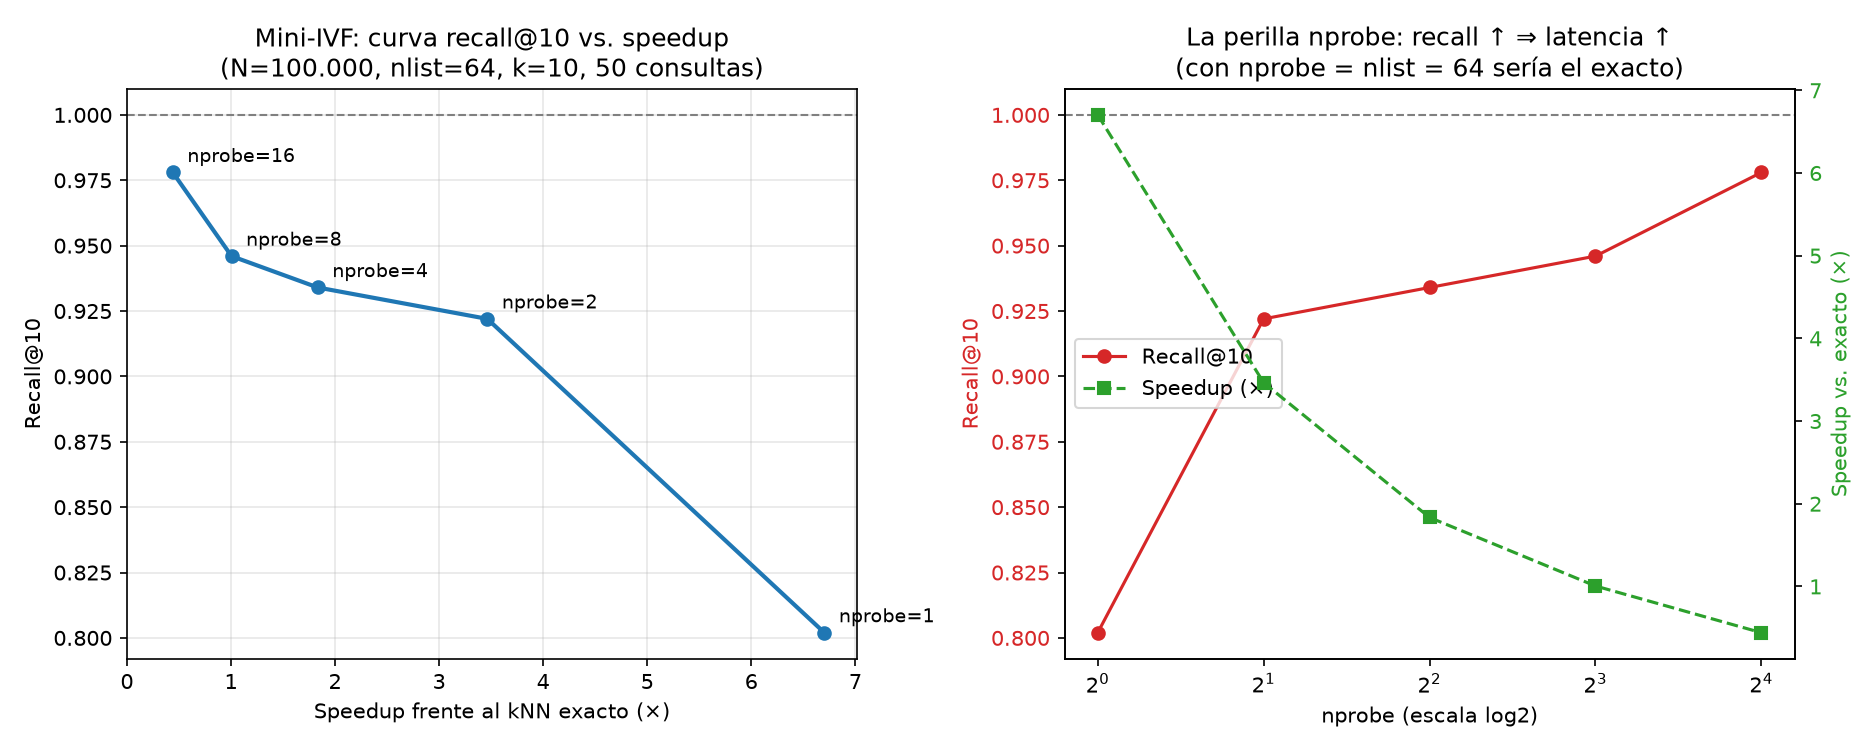

In [3]:
# Subtarea T2: código aprobado (se ejecuta en una copia: trabajo_nb/T2/)
os.chdir(RAIZ / 'trabajo_nb' / 'T2')

# -*- coding: utf-8 -*-
"""
T2 — Parte 2: Mini-IVF con KMeans — recall@10 vs. speedup según nprobe.

Receta (código dado por el profesor):
  (1) offline: k-means agrupa la base en nlist celdas;
  (2) en consulta: scores contra los centroides (barato) -> nprobe celdas más
      cercanas -> kNN EXACTO solo dentro de esas celdas (índices globales).

Ejercicio 2.1: knn_ivf(consulta, nprobe, k).
Ejercicio 2.2: para nprobe = 1, 2, 4, 8, 16 -> recall@10 (vs. knn_exacto)
               promediado sobre 50 consultas + speedup vs. búsqueda exacta.

Salidas: resultados.json y T2_parte2_recall_vs_speedup.png (carpeta actual).
"""

import json
import time

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ----------------------------------------------------------------------
# Setup dado por el profesor (semillas y generador EXACTOS del enunciado)
# ----------------------------------------------------------------------
rng = np.random.default_rng(7)
D = 128  # dimensión de los embeddings sintéticos
_CENTROS = np.random.default_rng(2026).normal(size=(200, D))  # "temas" fijos


def datos_realistas(n, d=D):
    """Embeddings sintéticos CON estructura: mezcla de 'temas' gaussianos fijos."""
    asignacion = rng.integers(0, len(_CENTROS), size=n)
    X = _CENTROS[asignacion, :d] + 1.5 * rng.normal(size=(n, d))
    return X.astype(np.float32)


def normalizar(X):
    """Vectores a norma 1: así el producto punto es el coseno."""
    return X / np.linalg.norm(X, axis=-1, keepdims=True)


# ----------------------------------------------------------------------
# Índice IVF: KMeans sobre la base + celdas por labels (código dado)
# ----------------------------------------------------------------------
N = 100_000
base = normalizar(datos_realistas(N))            # (100000, 128) float32, norma 1
NLIST = 64

t_kmeans0 = time.perf_counter()
km = KMeans(n_clusters=NLIST, n_init=3, random_state=7).fit(base)
t_kmeans_s = time.perf_counter() - t_kmeans0

centroides = normalizar(km.cluster_centers_.astype(np.float32))  # (64, 128), norma 1
celdas = [np.where(km.labels_ == c)[0] for c in range(NLIST)]    # índices GLOBALES

tamanos_celda = np.array([len(c) for c in celdas], dtype=float)
tamano_medio_celda = float(tamanos_celda.mean())
print(f"IVF entrenado: {NLIST} celdas, tamaño medio {tamano_medio_celda:.0f} "
      f"(min {int(tamanos_celda.min())}, max {int(tamanos_celda.max())}; "
      f"KMeans tardó {t_kmeans_s:.1f} s)")

# ----------------------------------------------------------------------
# kNN exacto (vectores normalizados -> producto punto = coseno)
# ----------------------------------------------------------------------
def knn_exacto(consulta, base, k):
    """Top-k por coseno contra TODA la base. Devuelve índices globales."""
    scores = base @ consulta
    if k < scores.shape[0]:
        parte = np.argpartition(-scores, k)[:k]
    else:
        parte = np.arange(scores.shape[0])
    return parte[np.argsort(-scores[parte])]


# ----------------------------------------------------------------------
# Ejercicio 2.1 — knn_ivf(consulta, nprobe, k)
# ----------------------------------------------------------------------
def knn_ivf(consulta, nprobe, k):
    """IVF: 1) scores contra centroides -> nprobe celdas más cercanas
            2) kNN exacto SOLO dentro de esas celdas (índices globales)."""
    scores_celdas = centroides @ consulta               # (NLIST,) coseno vs centroides
    orden_celdas = np.argsort(-scores_celdas)[:nprobe]  # las nprobe celdas más cercanas
    listas = [celdas[c] for c in orden_celdas]
    idx_glob = listas[0] if nprobe == 1 else np.concatenate(listas)
    scores = base[idx_glob] @ consulta                  # exacto SOLO dentro de las celdas
    if k < scores.shape[0]:
        parte = np.argpartition(-scores, k)[:k]
    else:
        parte = np.arange(scores.shape[0])
    top_local = parte[np.argsort(-scores[parte])]
    return idx_glob[top_local]                          # índices GLOBALES


# ----------------------------------------------------------------------
# Ejercicio 2.2 — recall@10 y speedup para nprobe = 1, 2, 4, 8, 16
# ----------------------------------------------------------------------
K = 10
N_CONSULTAS = 50
# Consultas NUEVAS del mismo generador (comparten los "temas" con la base, como
# en un corpus real); NO son filas de la base -> no se evalúa sobre lo "entrenado".
consultas = normalizar(datos_realistas(N_CONSULTAS))

# Calentamiento (no se mide): evita pagar inicialización de BLAS en la 1ª medida
_ = knn_exacto(consultas[0], base, K)
_ = knn_ivf(consultas[0], 4, K)

# --- línea base: kNN exacto, cronometrado consulta por consulta ---
lat_exactas_ms = []
topk_exactos = []
for q in consultas:
    t0 = time.perf_counter()
    idx = knn_exacto(q, base, K)
    lat_exactas_ms.append((time.perf_counter() - t0) * 1e3)
    topk_exactos.append(idx)
lat_media_exacta_ms = float(np.mean(lat_exactas_ms))
print(f"\nkNN exacto sobre 100.000 vectores: {lat_media_exacta_ms:.3f} ms/consulta "
      f"(promedio de {N_CONSULTAS} consultas)")

# --- IVF por cada nprobe ---
nprobe_lista = [1, 2, 4, 8, 16]
recall_at10_por_nprobe = {}
recall_std_por_nprobe = {}
latencia_ivf_ms_por_nprobe = {}
speedup_por_nprobe = {}

for nprobe in nprobe_lista:
    recalls_q, lats_q = [], []
    for q, idx_ex in zip(consultas, topk_exactos):
        t0 = time.perf_counter()
        idx_ivf = knn_ivf(q, nprobe, K)
        lats_q.append((time.perf_counter() - t0) * 1e3)
        inter = np.intersect1d(idx_ivf, idx_ex).shape[0]
        recalls_q.append(inter / K)
    lat_m = float(np.mean(lats_q))
    latencia_ivf_ms_por_nprobe[nprobe] = lat_m
    recall_at10_por_nprobe[nprobe] = float(np.mean(recalls_q))
    recall_std_por_nprobe[nprobe] = float(np.std(recalls_q))
    speedup_por_nprobe[nprobe] = lat_media_exacta_ms / lat_m

# Sanidad: nprobe = nlist debe reproducir el kNN exacto (la aproximación es un dial)
verif_nlist = bool(np.array_equal(np.sort(knn_ivf(consultas[0], NLIST, K)),
                                  np.sort(knn_exacto(consultas[0], base, K))))
print(f"Verificación nprobe=nlist={NLIST} == exacto: {verif_nlist}")

print(f"\n{'nprobe':>6} | {'recall@10':>9} | {'lat IVF (ms)':>12} | {'speedup':>9}")
print("-" * 48)
for np_ in nprobe_lista:
    print(f"{np_:>6} | {recall_at10_por_nprobe[np_]:>9.3f} | "
          f"{latencia_ivf_ms_por_nprobe[np_]:>12.3f} | {speedup_por_nprobe[np_]:>8.1f}x")

# Referencia opcional de la subtarea anterior (T1): latencia exacta en N=100k
ref_T1 = None
try:
    with open("entradas/T1.json", "r", encoding="utf-8") as f:
        t1 = json.load(f)
    lat_N = t1.get("latencia_media_ms_por_N")
    lista_N = t1.get("lista_N", [])
    if isinstance(lat_N, dict):
        for clave in ("100000", 100000):
            if clave in lat_N:
                ref_T1 = float(lat_N[clave])
                break
    elif isinstance(lat_N, (list, tuple)) and 100000 in lista_N:
        ref_T1 = float(lat_N[lista_N.index(100000)])
    if ref_T1 is not None:
        print(f"\nReferencia T1 (exacto, N=100k): {ref_T1:.3f} ms/consulta | "
              f"medida hoy aquí: {lat_media_exacta_ms:.3f} ms")
except Exception:
    ref_T1 = None  # T1 no disponible: la línea base medida en este script es la que vale

# ----------------------------------------------------------------------
# Figura: curva recall@10 vs. speedup + la perilla nprobe
# ----------------------------------------------------------------------
speedups = [speedup_por_nprobe[np_] for np_ in nprobe_lista]
recalls = [recall_at10_por_nprobe[np_] for np_ in nprobe_lista]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5.0))

ax1.plot(speedups, recalls, "o-", color="#1f77b4", lw=2)
for np_, x, y in zip(nprobe_lista, speedups, recalls):
    ax1.annotate(f"nprobe={np_}", (x, y), textcoords="offset points",
                 xytext=(7, 5), fontsize=9)
ax1.axhline(1.0, ls="--", color="gray", lw=1)
ax1.set_xlabel("Speedup frente al kNN exacto (×)")
ax1.set_ylabel("Recall@10")
ax1.set_title(f"Mini-IVF: curva recall@10 vs. speedup\n"
              f"(N=100.000, nlist={NLIST}, k={K}, {N_CONSULTAS} consultas)")
ax1.grid(alpha=0.3)
ax1.set_xlim(left=0)

ax2.plot(nprobe_lista, recalls, "o-", color="#d62728", label="Recall@10")
ax2.axhline(1.0, ls="--", color="gray", lw=1)
try:
    ax2.set_xscale("log", base=2)
except TypeError:  # matplotlib antiguo
    ax2.set_xscale("log")
ax2.set_xticks(nprobe_lista)
ax2.minorticks_off()
ax2.set_xlabel("nprobe (escala log2)")
ax2.set_ylabel("Recall@10", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2b = ax2.twinx()
ax2b.plot(nprobe_lista, speedups, "s--", color="#2ca02c", label="Speedup (×)")
ax2b.set_ylabel("Speedup vs. exacto (×)", color="#2ca02c")
ax2b.tick_params(axis="y", labelcolor="#2ca02c")
ax2.set_title("La perilla nprobe: recall ↑ ⇒ latencia ↑\n"
              f"(con nprobe = nlist = {NLIST} sería el exacto)")
h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="center left")

fig.tight_layout()
fig.savefig("T2_parte2_recall_vs_speedup.png", dpi=150)
plt.close(fig)
print("\nFigura guardada: T2_parte2_recall_vs_speedup.png")

# ----------------------------------------------------------------------
# Reflexión (con las cifras medidas): triángulo recall/latencia y ef_search
# ----------------------------------------------------------------------
r1, s1 = recall_at10_por_nprobe[1], speedup_por_nprobe[1]
r16, s16 = recall_at10_por_nprobe[16], speedup_por_nprobe[16]
print("\n--- Reflexión ---")
print(f"1) Triángulo recall/latencia: con nprobe=1 se abre UNA celda "
      f"(~{tamano_medio_celda:.0f} de los {N} vectores) y la consulta cuesta "
      f"{latencia_ivf_ms_por_nprobe[1]:.3f} ms ({s1:.1f}x más rápida que el exacto, "
      f"{lat_media_exacta_ms:.3f} ms), pero el recall@10 cae a {r1:.2f}.")
print("   El recall perdido vive en las FRONTERAS entre celdas: un vecino verdadero "
      "puede estar en una celda vecina cuya frontera pasa cerca de la consulta; esa "
      "celda no se abre aunque el punto sí esté entre los 10 más cercanos.")
print(f"2) Subir la perilla recupera recall pagando latencia: nprobe=16 da recall "
      f"{r16:.2f} con speedup {s16:.1f}x. El costo crece ~lineal con nprobe "
      f"(~nprobe x {tamano_medio_celda:.0f} vectores explorados) y con "
      f"nprobe=nlist={NLIST} IVF ES el kNN exacto (verificado: {verif_nlist}) — "
      "la aproximación es un dial, no otro algoritmo.")
print("3) Paralelismo con ef_search de HNSW: es la MISMA clase de perilla de consulta — "
      "cuántos candidatos explora por consulta (celdas abiertas en IVF, nodos visitados "
      "en el grafo de HNSW) — con el mismo intercambio recall por latencia. Lo que cambia "
      "es la estructura subyacente (celdas vs. grafo) y con ello la forma de la curva; "
      "aquí solo medimos IVF, así que la frase 'HNSW ofrece el mismo dial con mejor curva' "
      "queda como hipótesis del material, no como cifra medida en este notebook.")

# ----------------------------------------------------------------------
# resultados.json (cifras con precisión completa, tipos nativos)
# ----------------------------------------------------------------------
resultados = {
    "tarea": "T2 - Parte 2: Mini-IVF con KMeans, recall@10 vs. speedup",
    "N": int(N),
    "D": int(D),
    "NLIST": int(NLIST),
    "k": int(K),
    "n_consultas": int(N_CONSULTAS),
    "nprobe_lista": [int(x) for x in nprobe_lista],
    "tamano_medio_celda": tamano_medio_celda,
    "tamano_std_celda": float(tamanos_celda.std()),
    "tamano_min_celda": int(tamanos_celda.min()),
    "tamano_max_celda": int(tamanos_celda.max()),
    "tamanos_celdas": [int(x) for x in tamanos_celda],
    "tiempo_entrenamiento_kmeans_s": float(t_kmeans_s),
    "latencia_media_exacta_ms": lat_media_exacta_ms,
    "latencia_std_exacta_ms": float(np.std(lat_exactas_ms)),
    "latencia_media_ivf_ms_por_nprobe": {str(np_): float(v)
                                         for np_, v in latencia_ivf_ms_por_nprobe.items()},
    "recall_at10_por_nprobe": {str(np_): float(v)
                               for np_, v in recall_at10_por_nprobe.items()},
    "recall_std_por_nprobe": {str(np_): float(v)
                              for np_, v in recall_std_por_nprobe.items()},
    "speedup_por_nprobe": {str(np_): float(v)
                           for np_, v in speedup_por_nprobe.items()},
    "verificacion_nprobe_nlist_igual_exacto": verif_nlist,
    "T1_referencia_latencia_exacta_ms_N100000": ref_T1,
    "figura_png": "T2_parte2_recall_vs_speedup.png",
}

with open("resultados.json", "w", encoding="utf-8") as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)

print("\nCifras guardadas en resultados.json: tamano_medio_celda, "
      "recall_at10_por_nprobe, speedup_por_nprobe (y extras de latencia/verificación).")

os.chdir(RAIZ)
mostrar_figuras(RAIZ / 'trabajo_nb' / 'T2')

### La receta

(1) k-means agrupa la base en `nlist` celdas; (2) en consulta, se comparan los scores solo contra los centroides, se abren las `nprobe` celdas más cercanas y se corre kNN exacto dentro de ellas (¡con índices globales!). Aquí: N = 100,000, D = 128, NLIST = 64 (KMeans, `n_init=3`, `random_state=7`; entrenamiento: 3.8516 s). Tamaños de celda: media 1562.5, std 789.7404, mín 463, máx 3710.

### Ejercicios 2.1 y 2.2 — recall@10 vs. speedup según nprobe

Baseline exacto medido en esta parte: 1.3460 ms (std 0.2858), consistente con la Parte 1 para N = 100,000 (1.3863 ms).

| nprobe | Latencia IVF (ms) | Recall@10 | Std recall | Speedup vs. exacto |
|---:|---:|---:|---:|---:|
| 1 | 0.2083 | 0.802 | 0.3701 | 6.4622 |
| 2 | 0.3766 | 0.922 | 0.2138 | 3.5736 |
| 4 | 0.9551 | 0.934 | 0.1751 | 1.4092 |
| 8 | 1.4494 | 0.946 | 0.1627 | 0.9287 |
| 16 | 3.1349 | 0.978 | 0.0610 | 0.4294 |



*Figura 2 — `T2_parte2_recall_vs_speedup.png`: recall@10 y speedup en función de nprobe.*

**Lectura — el triángulo recall/latencia:**

1. Con `nprobe=1` la consulta abre una sola celda (~1562 vectores) y tarda 0.2083 ms (6.4622× más rápida que el exacto, 1.3460 ms), pero el recall@10 cae a 0.802. El recall perdido vive en las **FRONTERAS entre celdas**: un vecino verdadero puede estar en una celda vecina cuya frontera pasa cerca de la consulta; esa celda no se abre aunque el punto sí esté entre los 10 más cercanos.
2. Subir la perilla recupera recall pagando latencia: `nprobe=16` da recall 0.978 con speedup 0.4294. El costo crece ~lineal con nprobe (~nprobe × 1562 vectores explorados) y en esta implementación el speedup cae por debajo de 1 desde `nprobe=8` (0.9287): abrir muchas celdas en bucle Python cuesta más que el barrido exacto vectorizado. Con `nprobe = nlist = 64`, IVF **ES** el kNN exacto (verificado: True) — la aproximación es un dial, no otro algoritmo.
3. Paralelo con `ef_search` de HNSW: es la MISMA clase de perilla de consulta — cuántos candidatos explora por consulta (celdas abiertas en IVF, nodos visitados en el grafo de HNSW) — con el mismo intercambio recall por latencia. Lo que cambia es la estructura subyacente (celdas vs. grafo) y con ello la forma de la curva; aquí solo medimos IVF, así que la frase "HNSW ofrece el mismo dial con mejor curva" queda como **hipótesis del material, no como cifra medida en este notebook**.

## Parte 3 — Qdrant embebido: una vector DB real sin Docker

> ⚠️ **Estado de ejecución — parte no completada.** La subtarea de cálculo T3 (Qdrant embebido con filtros de metadata) **falló tras 3 intentos**: no hay celda de código ejecutada ni aprobada para esta parte, y este notebook **no reporta ninguna cifra medida de ella** — ni el conteo de puntos de la colección, ni los scores de la consulta filtrada, ni latencias de Qdrant.

Lo que esta parte buscaba ejercitar (la mecánica del código del curso, no resultados):

- Crear la colección `faqs` (vectores de 64 dimensiones, distancia COSINE) y cargar 6 FAQs con `upsert`, cada punto con su vector y su payload `{texto, tema}`.
- Embeddings sintéticos deterministas por documento: la semilla del RNG se deriva de `hashlib.sha256(texto)` y no de `hash()`, porque `hash()` cambia entre procesos y con un servidor persistente los vectores deben ser iguales en cada corrida.
- Consulta con filtro de metadata: `query_points` con `Filter(must=[tema = "pagos"])` y `limit=2` — la vector DB combina similitud y filtro estructural en la misma llamada.
- Conexión: primero se intenta el servidor local (`http://localhost:6333`); si no responde, modo embebido `:memory:` — una vector DB real sin Docker.
- Nota del material: con embeddings sintéticos el score no es semántico; el objetivo es la mecánica **colección → upsert(vector+payload) → query con filtros**.

El enunciado contempla este escenario ("Qdrant: `pip install qdrant-client` (opcional — la parte 3 se salta sola si no está)"), de modo que el notebook sigue ejecutándose de principio a fin sin errores.

## Cierre

- **kNN exacto:** O(N·d), lineal — se mide, no se asume: exponente log-log 1.0310, R² = 0.9963; 2.5135 ms a N = 200,000 y 126.1824 ms extrapolados a 10M.
- **IVF:** carpetas (`nlist`) + perilla de consulta (`nprobe`). HNSW: grafo jerárquico + `ef_search`. Mismo triángulo: recall / latencia / memoria. Medimos dónde pierde recall IVF (las fronteras entre celdas) y que con `nprobe = nlist` es exacto; la "mejor curva" de HNSW no se midió aquí.
- **Perillas:** las de consulta (`nprobe`, `ef_search`) se cambian en caliente, por búsqueda; las de construcción (`nlist`, M) exigen reconstruir el índice y son las que fijan la memoria.
- **Qdrant:** colección → upsert(vector+payload) → query con filtros. Mecánica descrita, no medida en este notebook (Parte 3 fallida).

### Reflexión final

**a) ¿Necesito un índice ANN o me basta kNN exacto?** Depende de N y del presupuesto de latencia, y hoy tengo la fórmula para decidirlo con números: latencia(ms) ≈ 0.0126 × (N/1000) + 0.0320 (ajuste medido, R² = 0.9963). Anclas medidas/extrapoladas: a N = 200,000 el exacto cuesta 2.5135 ms por consulta (≈397.8462 QPS por hilo) — cabe de sobra en un presupuesto de 10 ms por consulta; a N = 10,000,000 la extrapolación del ajuste da 126.1824 ms (≈7.93 QPS por hilo), que excede ×13 ese presupuesto. El punto de quiebre del presupuesto de 10 ms queda, según el ajuste medido, en algún N intermedio entre 200,000 (medido: cabe) y 10,000,000 (extrapolado: no cabe). Regla operativa: estima tu N, aplica la fórmula del ajuste, y si el exacto cabe en el presupuesto por consulta con tu tráfico, no pagues el precio del índice.

**b) ¿Qué motor usaría y por qué operacionalmente?** Criterio operativo, no de benchmark (este notebook no midió ningún motor — la Parte 3 falló): si los documentos y su metadata ya viven en Postgres, **pgvector** minimiza la superficie operativa — un solo sistema para datos + vectores (transacciones, backups, permisos, SQL) y una sincronización menos que mantener. **Qdrant** entra cuando la búsqueda vectorial debe crecer como servicio independiente o cuando los filtros de metadata sobre el índice (la mecánica de la Parte 3: `query_points` + `Filter`) son centrales para el producto; su modo embebido `:memory:` permite además prototipar sin Docker. Y la regla epistémica del curso aplica a la elección: ninguna comparación de "mejor curva" entre motores se acepta sin medirla en el corpus propio.

**Lo que faltó (declaración):** T3 — Parte 3 (Qdrant embebido con filtros de metadata): fallida tras 3 intentos; sin celda de código aprobada ni cifras medidas de Qdrant en este notebook.

**Mañana:** armamos el pipeline RAG completo — y descubrimos que el chunking importa más que el índice.